In [2]:
import torch
print(torch.__version__)

2.10.0+cpu


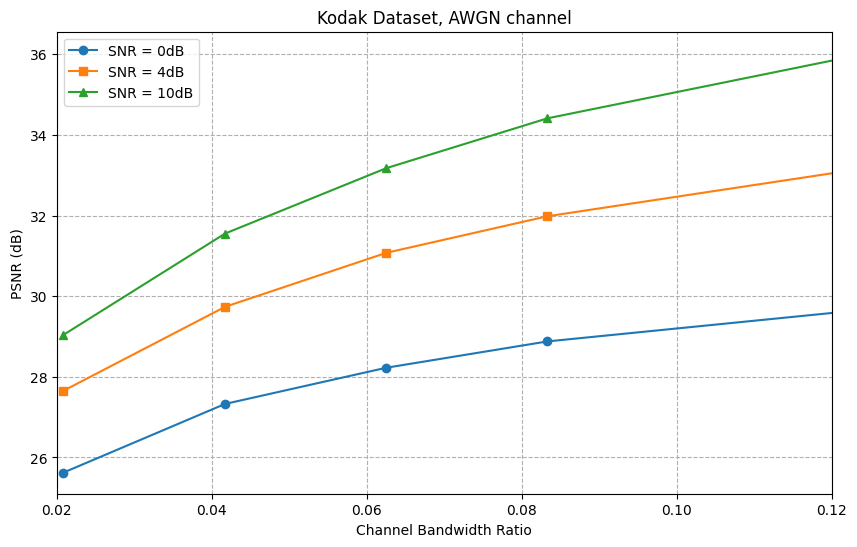

In [1]:
import matplotlib.pyplot as plt
import numpy as np

cbr_snr = [0.0208, 0.0417, 0.0625, 0.0833, 0.1250]
psnr_snr0 = [25.62028114994367, 27.326929569244385, 28.224804004033405, 28.878015478452046, 29.67976063489914]

psnr_snr4 = [27.649431029955547, 29.7361155351003, 31.075219710667927, 31.98322554429372, 33.19405754407247]

psnr_snr10 = [29.035442173480988, 31.5540744860967, 33.17551712195078, 34.412529269854225, 36.03980332612991]


plt.figure(figsize=(10, 6))

plt.plot(cbr_snr, psnr_snr0, marker='o', linestyle='-', label='SNR = 0dB')
plt.plot(cbr_snr, psnr_snr4, marker='s', linestyle='-', label='SNR = 4dB')
plt.plot(cbr_snr, psnr_snr10, marker='^', linestyle='-', label='SNR = 10dB')

plt.xlabel('Channel Bandwidth Ratio')
plt.ylabel('PSNR (dB)')
plt.title('Kodak Dataset, AWGN channel')

plt.legend()
plt.grid(True, which='both', linestyle='--')

plt.xlim(0.02, 0.12)

# Save the plot as a PNG file in folder
plt.savefig('kodak_awgn_psnr_vs_cbr.png', dpi=300)

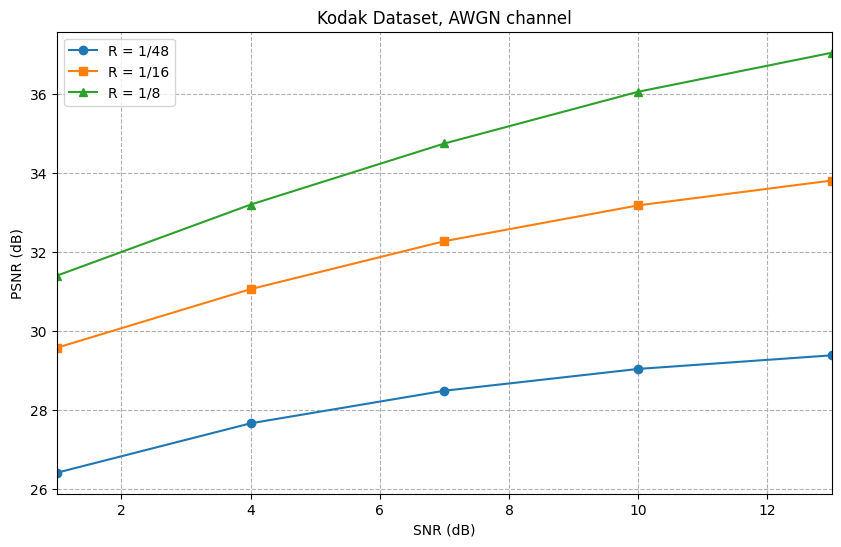

In [4]:
snrs = [1, 4, 7, 10, 13]
# psnr_cbr148 = [26.41344928741455, 27.63921062151591, 28.4744208653, 29.027129809061687, 29.381730635960896]

# psnr_snr116 = [29.54400380452474, 31.069985787073772, 32.26123889287313, 33.17510151863098, 33.79]

# psnr_snr10 = [31.4, 33.2, 34.75, 36.048, 37.049]

psnr_cbr148 = [26.41344928741455, 27.663908402125042, 28.48810255, 29.03971602519353, 29.384222229321797]

psnr_snr116 = [29.576009809970856, 31.059279243151348, 32.273033459981285, 33.17783921957016, 33.80740920]

psnr_snr10 = [31.4, 33.19831371307373, 34.744008580843605, 36.0530169804891, 37.04090674718221]


plt.figure(figsize=(10, 6))

plt.plot(snrs, psnr_cbr148, marker='o', linestyle='-', label='R = 1/48')
plt.plot(snrs, psnr_snr116, marker='s', linestyle='-', label='R = 1/16')
plt.plot(snrs, psnr_snr10, marker='^', linestyle='-', label='R = 1/8')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')
plt.title('Kodak Dataset, AWGN channel')

plt.legend()
plt.grid(True, which='both', linestyle='--')

plt.xlim(1, 13)

plt.savefig('kodak_awgn_psnr_vs_snr_2.png', dpi=300)

Deep JSCC

In [4]:
import numpy as np

SNR = np.array([0,4,7,10,13,19])

bpg_lpdc = np.where(SNR <= 12, 6.57, 33.57)
bpg_ldpc_bpsk = np.where(SNR <= 4, 6.4, 21.66)
bpg_lpdc_4qam = np.where(SNR <= 7, 6.5, 24.56)

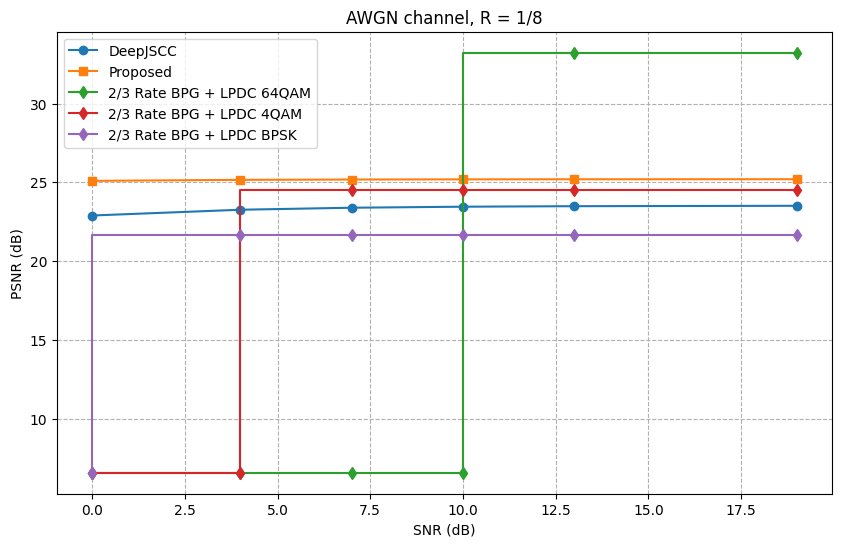

In [3]:
# PSNR
CBR = 0.0125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [25.09389305114746, 25.157034873962402, 25.177648067474365, 25.188952445983887, 25.19339418411255, 25.197562217712402]
djscc_psnr = [22.89270520210266, 23.2595534324646, 23.387324333190918, 23.452386379241943, 23.485010862350464, 23.510085582733154]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [6.57, 6.57, 6.57, 6.57, 33.23, 33.23]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [6.56, 21.64, 21.64, 21.64, 21.64, 21.64]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [6.57, 6.57, 24.54, 24.54, 24.54, 24.54]

plt.figure(figsize=(10, 6))
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Proposed')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/8')

plt.legend()
plt.grid(True, which='both', linestyle='--')



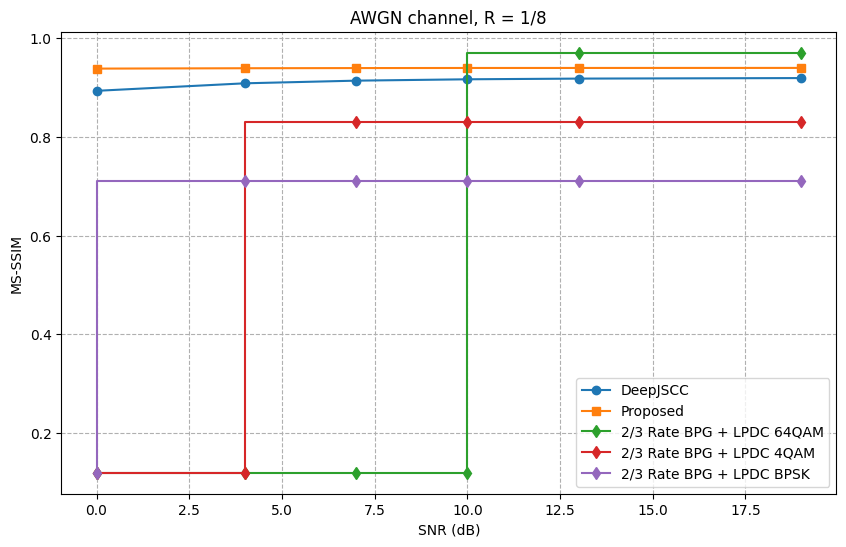

In [5]:
# MS-SSIM
CBR = 0.0125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [0.937849747017026, 0.938598844781518, 0.9389270529150963, 0.939128239825368, 0.9391711380332708, 0.939262418076396]
djscc_psnr = [0.8928767435252667, 0.9080969505012035, 0.9134676322340965, 0.916225965321064, 0.9176259748637676, 0.9187026269733906]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [0.12, 0.12, 0.12, 0.12, 0.97, 0.97]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [0.12, 0.71, 0.71, 0.71, 0.71, 0.71]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [0.12, 0.12, 0.83, 0.83, 0.83, 0.83]

plt.figure(figsize=(10, 6))
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Proposed')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('MS-SSIM')

plt.title('AWGN channel, R = 1/8')

plt.legend()
plt.grid(True, which='both', linestyle='--')



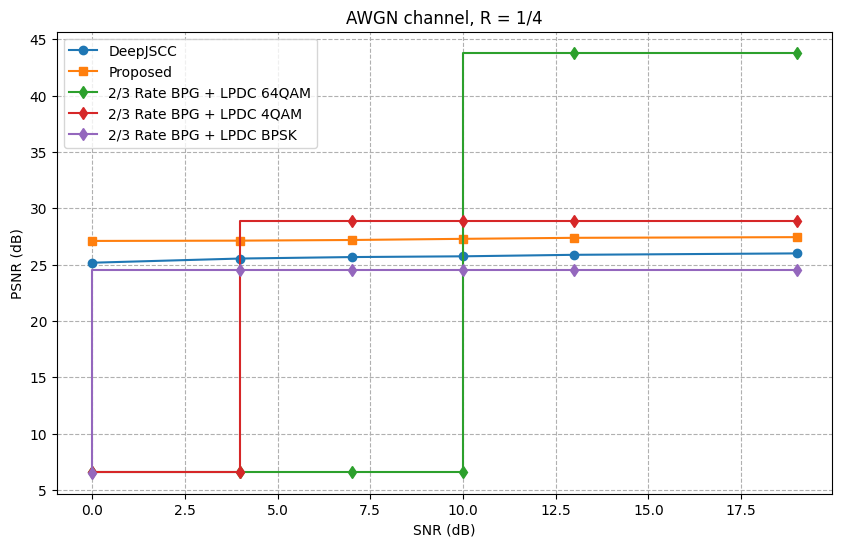

In [7]:
CBR = 0.025
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [27.09389305114746, 27.12, 27.177648067474365, 27.28, 27.37, 27.43]
djscc_psnr = [25.159621715545654, 25.53203582763672, 25.66236448287964, 25.72867226600647, 25.86234531402588, 25.987861824035645]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [6.57, 6.57, 6.57, 6.57, 43.8, 43.8]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [6.52, 24.52, 24.52, 24.52, 24.52, 24.52]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [6.57, 6.57, 28.84, 28.84, 28.84, 28.84]

plt.figure(figsize=(10, 6))
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Proposed')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/4')

plt.legend()
plt.grid(True, which='both', linestyle='--')



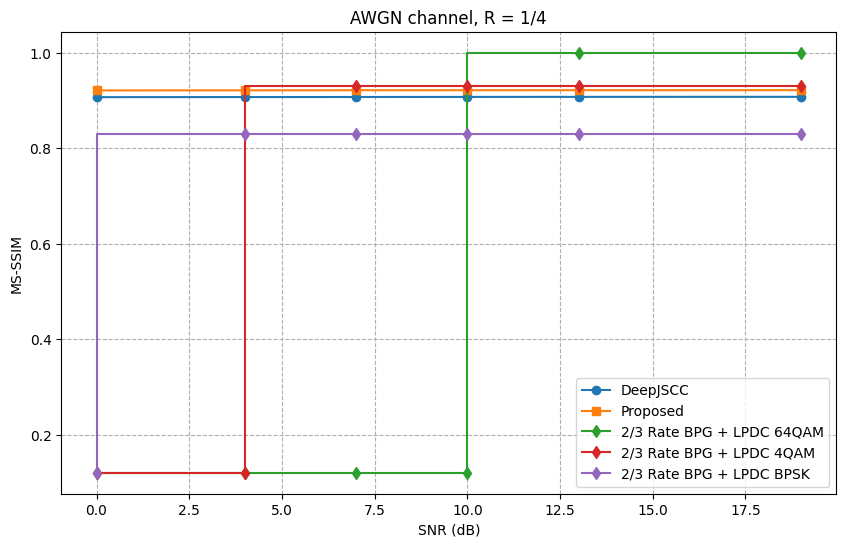

In [7]:
CBR = 0.025
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [0.921, 0.921223321, 0.9214407, 0.92149, 0.92152, 0.92159]
djscc_psnr = [0.9069, 0.9071, 0.90723, 0.9074, 0.9075, 0.9076]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [0.12, 0.12, 0.12, 0.12, 1, 1]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [0.12, 0.83, 0.83, 0.83, 0.83, 0.83]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [0.12, 0.12, 0.93, 0.93, 0.93, 0.93]

plt.figure(figsize=(10, 6))
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Proposed')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('MS-SSIM')

plt.title('AWGN channel, R = 1/4')

plt.legend()
plt.grid(True, which='both', linestyle='--')



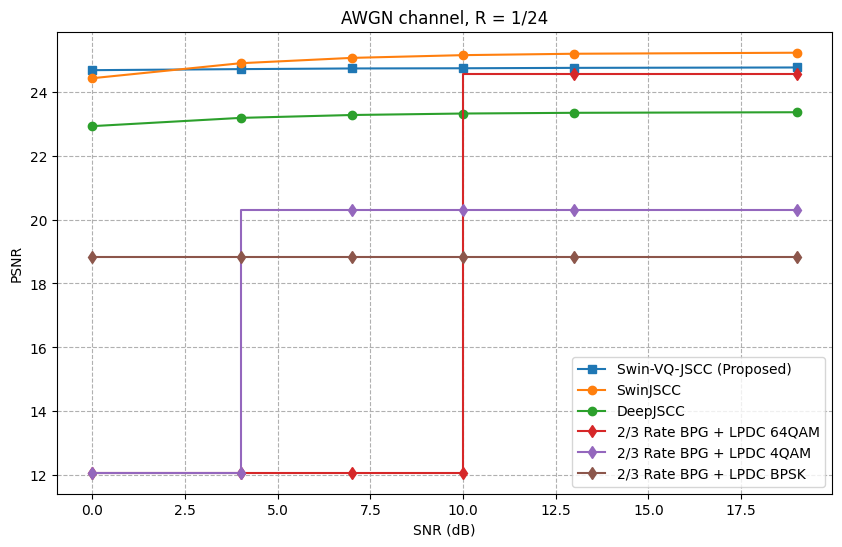

In [36]:
CBR = 1/24
SNR = [0,4,7,10,13,19]
swinjscc_psnr = [24.42233395576477, 24.891651391983032, 25.05842113494873, 25.14420771598816, 25.18788766860962, 25.21996545791626]
swin_vq_psnr = [24.67411518096924, 24.707082986831665, 24.727535972595215, 24.73362780570984, 24.746255655288696, 24.758451013565063]
djscc_psnr = [22.922988891601562, 23.181316614151, 23.271451950073242, 23.317680835723877, 23.340161085128784, 23.357943058013916]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [18.83, 18.83, 18.83, 18.83, 18.83, 18.83]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [12.08, 12.08, 20.3, 20.3, 20.3, 20.3]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [12.08, 12.08, 12.08, 12.08, 24.55, 24.55]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC (Proposed)')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR')

plt.title('AWGN channel, R = 1/24')

plt.legend()
plt.grid(True, which='both', linestyle='--')


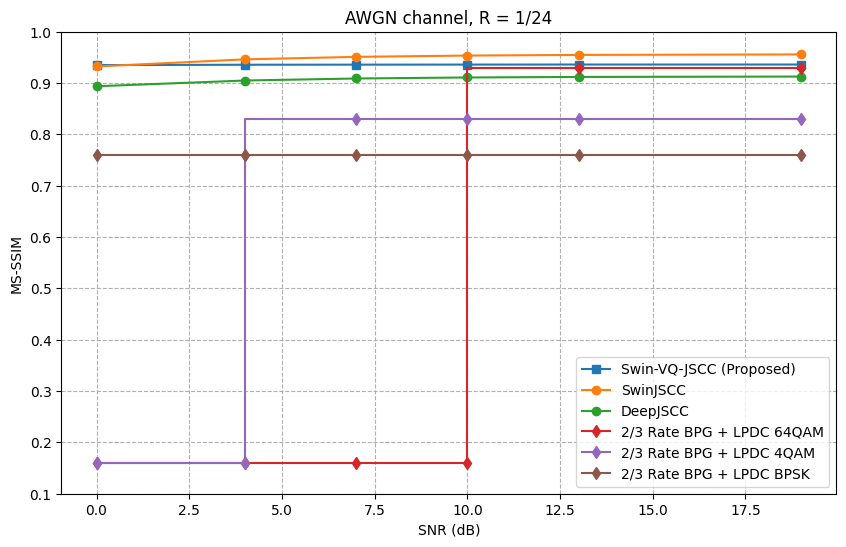

In [38]:
CBR = 1/24
SNR = [0,4,7,10,13,19]
swinjscc_psnr = [0.9322873234748841, 0.9461467150598765, 0.951044499129057, 0.953535158187151, 0.9548255581408739, 0.955768633633852]
swin_vq_psnr = [0.9349694184958934, 0.9356673531234264, 0.9358559913933278, 0.9359918639063836, 0.936070067435503, 0.9360973916947841]
djscc_psnr = [0.893751572072506, 0.9049195863306523, 0.9088846787810325, 0.910864569991827, 0.9119030252099037, 0.9126630194485188]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [0.76, 0.76, 0.76, 0.76, 0.76, 0.76]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [0.16, 0.16, 0.83, 0.83, 0.83, 0.83]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [0.16, 0.16, 0.16, 0.16, 0.93, 0.93]


plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC (Proposed)')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('MS-SSIM')

plt.title('AWGN channel, R = 1/24')

plt.yticks(np.arange(0.1, 1.1, 0.1))
plt.ylim(0.1, 1.0)

plt.legend()
plt.grid(True, which='both', linestyle='--')


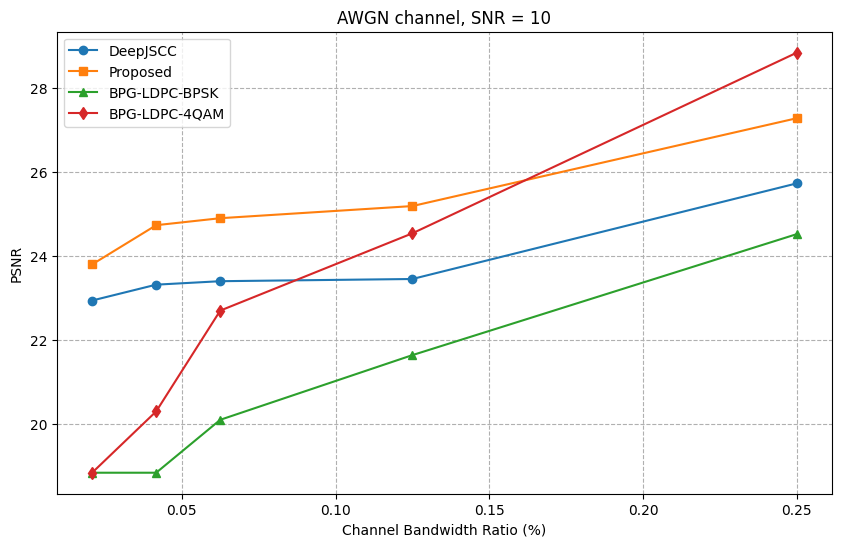

In [5]:
# SNR = 10
CBR = [1/48, 1/24, 1/16, 1/8, 1/4]

swin_vq_psnr = [23.8, 24.73362780570984, 24.9, 25.188952445983887, 27.28]
deepjscc_psnr = [22.94, 23.317680835723877, 23.4, 23.452386379241943, 25.72867226600647]
bpg_ldpc_bpsk = [18.84, 18.84, 20.1, 21.64, 24.52]
bpg_ldpc_4qam = [18.84, 20.3, 22.7, 24.54, 28.84]
# bpg_ldpc_64qam = [6.57, 24.55, 28.7, 33.23, 43.8]

# plot
plt.figure(figsize=(10, 6))
plt.plot(CBR, deepjscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.plot(CBR, swin_vq_psnr, marker='s', linestyle='-', label='Proposed')
plt.plot(CBR, bpg_ldpc_bpsk, marker='^', linestyle='-', label='BPG-LDPC-BPSK')
plt.plot(CBR, bpg_ldpc_4qam, marker='d', linestyle='-', label='BPG-LDPC-4QAM')
# plt.plot(CBR, bpg_ldpc_64qam, marker='*', linestyle='-', label='BPG-LDPC-64QAM')
plt.xlabel('Channel Bandwidth Ratio (%)')
plt.ylabel('PSNR')

plt.title('AWGN channel, SNR = 10')

plt.legend()
plt.grid(True, which='both', linestyle='--')

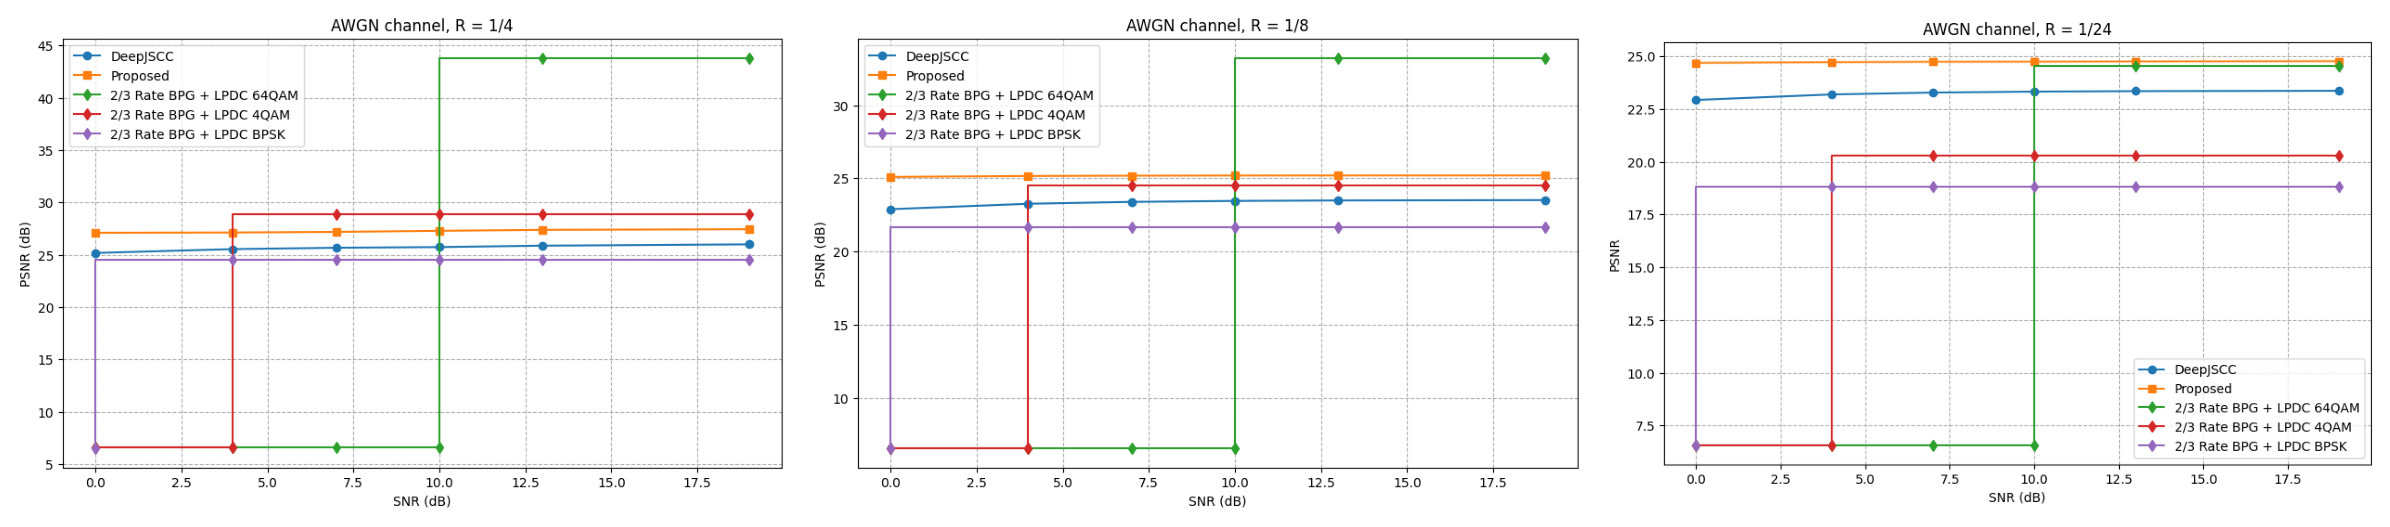

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# Load images
img1 = Image.open("R4.png")
img2 = Image.open("R8.png")
img3 = Image.open("R24.png")

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Display images
axes[0].imshow(img1)
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].axis("off")

# Adjust spacing
plt.tight_layout()

# Show figure
plt.show()

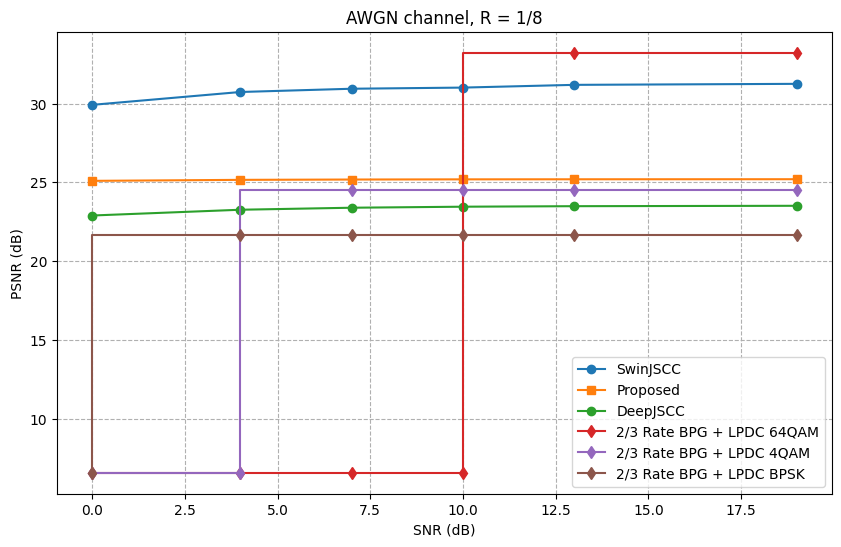

In [ ]:
# PSNR
CBR = 0.125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [25.09389305114746, 25.157034873962402, 25.177648067474365, 25.188952445983887, 25.19339418411255, 25.197562217712402]
swinjscc_psnr = [29.919492483139038, 30.736189126968384, 30.94305076599121, 31.015705165863037, 31.18961443901062, 31.253931665420532]
djscc_psnr = [22.89270520210266, 23.2595534324646, 23.387324333190918, 23.452386379241943, 23.485010862350464, 23.510085582733154]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [6.57, 6.57, 6.57, 6.57, 33.23, 33.23]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [6.56, 21.64, 21.64, 21.64, 21.64, 21.64]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [6.57, 6.57, 24.54, 24.54, 24.54, 24.54]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Proposed')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/8')

plt.legend()
plt.grid(True, which='both', linestyle='--')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/8')

plt.legend()
plt.grid(True, which='both', linestyle='--')



In [11]:
import os
print(os.getcwd())

c:\Code\PythonProject\SwinJSCC_implementation\src


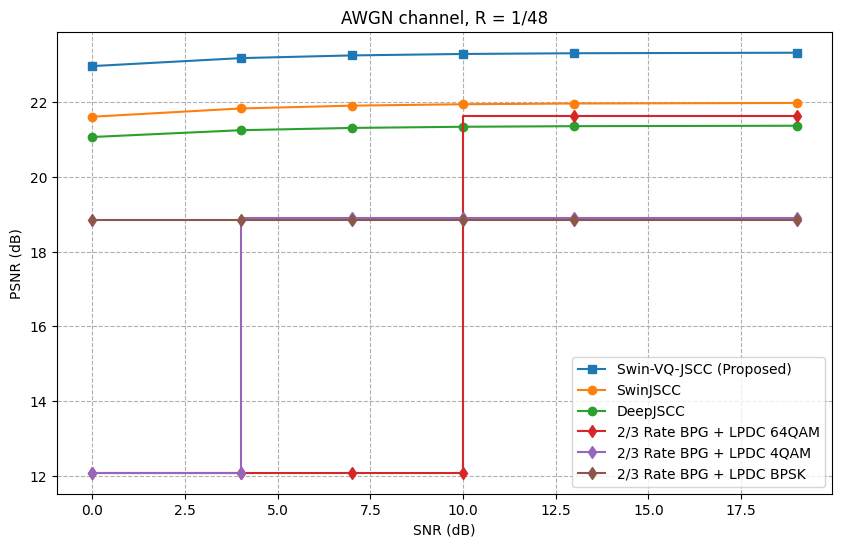

In [41]:
# PSNR: [[22.312018632888794], [22.509272813796997], [22.576472997665405], [22.609660625457764], [22.62707233428955], [22.638633489608765]]
# MS-SSIM: [[0.8801831111311913], [0.8899656504392623], [0.8932485662400722], [0.8949869558215141], [0.8958400264382362], [0.8964569181203842]]

# PSNR: [[21.607484579086304], [21.82937479019165], [21.904258728027344], [21.942320823669434], [21.961781978607178], [21.976530075073242]]
# MS-SSIM: [[0.8645879298448562], [0.8781578004360199], [0.8830107301473618], [0.885546263307333], [0.8868561498820782], [0.8878495067358017]]

CBR = 0.0125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [22.96278429031372, 23.17637586593628, 23.248942136764526, 23.287650108337402, 23.30705428123474, 23.320900201797485]
swinjscc_psnr = [21.607484579086304, 21.82937479019165, 21.904258728027344, 21.942320823669434, 21.961781978607178, 21.976530075073242]
djscc_psnr = [21.06544041633606, 21.246793270111084, 21.308318614959717, 21.33908176422119, 21.355137825012207, 21.366621255874634]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [18.84, 18.84, 18.84, 18.84, 18.84, 18.84]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [12.08, 12.08, 18.9, 18.9, 18.9, 18.9]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [12.08, 12.08, 12.08, 12.08, 21.64, 21.64]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC (Proposed)')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/48')

plt.legend()
plt.grid(True, which='both', linestyle='--')

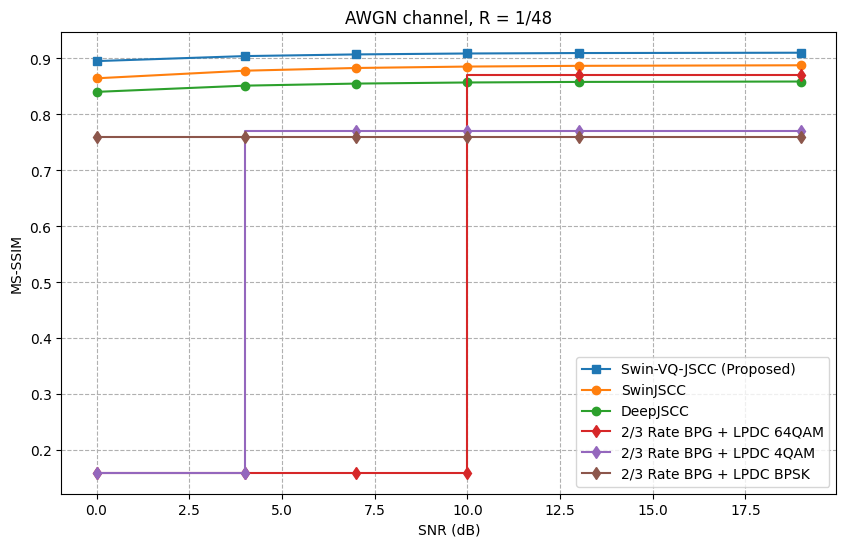

In [40]:
CBR = 0.0125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [0.8953302040696144, 0.9042643040418625, 0.9072530977427959, 0.9089021936058999, 0.9096944026648999, 0.910274101793766]
swinjscc_psnr = [0.8645879298448562, 0.8781578004360199, 0.8830107301473618, 0.885546263307333, 0.8868561498820782, 0.8878495067358017]
djscc_psnr = [0.8403395101428032, 0.8514461413025856, 0.8551450237631798, 0.8571210980415345, 0.8581178516149521, 0.8588331371545792]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [0.76, 0.76, 0.76, 0.76, 0.76, 0.76]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [0.16, 0.16, 0.77, 0.77, 0.77, 0.77]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [0.16, 0.16, 0.16, 0.16, 0.87, 0.87]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC (Proposed)')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('MS-SSIM')

plt.title('AWGN channel, R = 1/48')

plt.legend()
plt.grid(True, which='both', linestyle='--')

In [ ]:
# 1/48, 1/24, 1/36

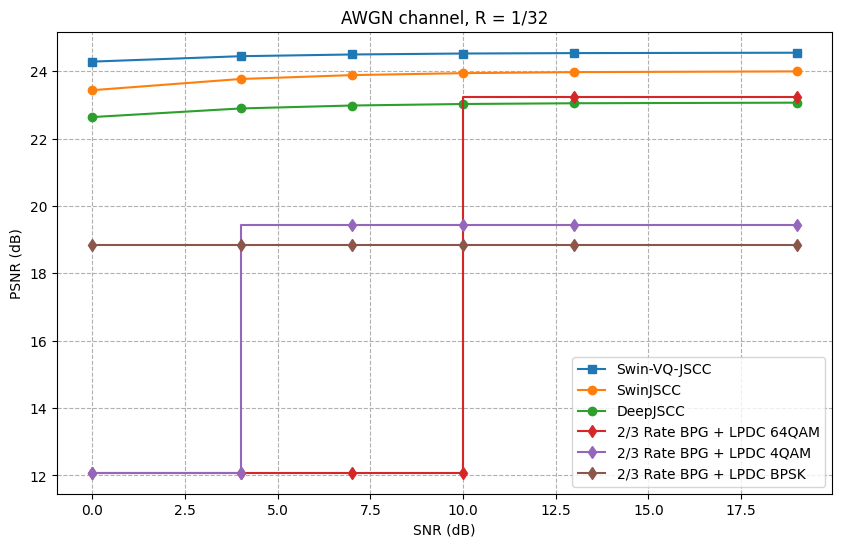

In [44]:
# 1/32 C = 3

# Swin-VQ-JSCC
# PSNR: [[24.285250663757324], [24.44588613510132], [24.49699115753174], [24.525427103042603], [24.538039684295654], [24.549203872680664]]
# MS-SSIM: [[0.927475418895483], [0.9314405582845211], [0.9326453037559986], [0.9333060279488563], [0.9335839353501797], [0.9338584795594216]]
# DeepJSCC
# PSNR: [[22.63872718811035], [22.89457082748413], [22.98185658454895], [23.02687931060791], [23.048906087875366], [23.066277265548706]]
# MS-SSIM: [[0.8835530161857605], [0.8954450458288192], [0.8995559826493263], [0.9017147786915303], [0.9027673289179802], [0.9035806559026242]]
# SwinJSCC
# PSNR: [[23.43662142753601], [23.769415855407715], [23.884358167648315], [23.94284987449646], [23.973016262054443], [23.99523138999939]]
# MS-SSIM: [[0.911672355979681], [0.9245985254645348], [0.9290539473295212], [0.9313532814383507], [0.9325293347239494], [0.9334048613905906]]
CBR = 0.03125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [24.285250663757324, 24.44588613510132, 24.49699115753174, 24.525427103042603, 24.538039684295654, 24.549203872680664]
swinjscc_psnr = [23.43662142753601, 23.769415855407715, 23.884358167648315, 23.94284987449646, 23.973016262054443, 23.99523138999939]
djscc_psnr = [22.63872718811035, 22.89457082748413, 22.98185658454895, 23.02687931060791, 23.048906087875366, 23.066277265548706]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [18.84, 18.84, 18.84, 18.84, 18.84, 18.84]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [12.08, 12.08, 19.44, 19.44, 19.44, 19.44]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [12.08, 12.08, 12.08, 12.08, 23.22, 23.22]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/32')

plt.legend()
plt.grid(True, which='both', linestyle='--')

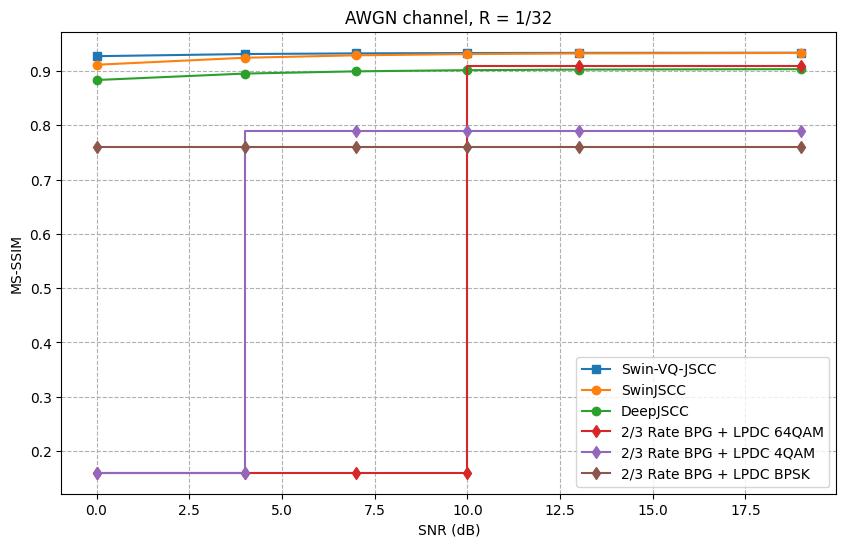

In [43]:
CBR = 0.03125
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [0.927475418895483, 0.9314405582845211, 0.9326453037559986, 0.9333060279488563, 0.9335839353501797, 0.9338584795594216]
swinjscc_psnr = [0.911672355979681, 0.9245985254645348, 0.9290539473295212, 0.9313532814383507, 0.9325293347239494, 0.9334048613905906]
djscc_psnr = [0.8835530161857605, 0.8954450458288192, 0.8995559826493263, 0.9017147786915303, 0.9027673289179802, 0.9035806559026242]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [0.76, 0.76, 0.76, 0.76, 0.76, 0.76]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [0.16, 0.16, 0.79, 0.79, 0.79, 0.79]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [0.16, 0.16, 0.16, 0.16, 0.91, 0.91]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('MS-SSIM')

plt.title('AWGN channel, R = 1/32')

plt.legend()
plt.grid(True, which='both', linestyle='--')

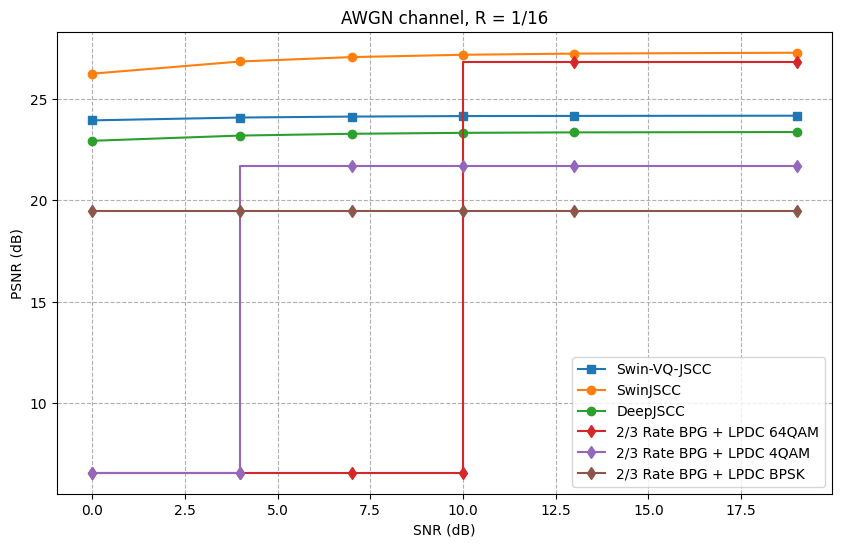

In [5]:
# 1/16 C = 6 
# SwinJSCC
# PSNR: [[26.2392156124115], [26.840668439865112], [27.05699062347412], [27.170867919921875], [27.228396892547607], [27.27209186553955]]
# MS-SSIM: [[0.9566245276480914], [0.9685673037543893], [0.9726961834356189], [0.9748385407030582], [0.9759048443287611], [0.9767219100147486]]
# Swin-VQ-JSCC
# PSNR: [[23.937255859375], [24.077964067459106], [24.12431764602661], [24.149609088897705], [24.157329320907593], [24.168291330337524]]
# MS-SSIM: [[0.9163124904036521], [0.9200054369866848], [0.9211288958787918], [0.9218149013817311], [0.9219718620181083], [0.9222604349255562]]
# DeepJSCC
# PSNR: [[22.930800199508667], [23.189096212387085], [23.27678608894348], [23.3227756023407], [23.34569478034973], [23.362937688827515]]
# MS-SSIM: [[0.894732890278101], [0.9062687769532204], [0.910221254080534], [0.9122851215302944], [0.9133302345871925], [0.9141058206558228]]
CBR = 0.0625
SNR = [0,4,7,10,13,19]
swin_vq_psnr = [23.937255859375, 24.077964067459106, 24.12431764602661, 24.149609088897705, 24.157329320907593, 24.168291330337524]
swinjscc_psnr = [26.2392156124115, 26.840668439865112, 27.05699062347412, 27.170867919921875, 27.228396892547607, 27.27209186553955]
djscc_psnr = [22.930800199508667, 23.189096212387085, 23.27678608894348, 23.3227756023407, 23.34569478034973, 23.362937688827515]
# 2/3 Rate BPG + LPDC + BPSK
bpg_ldpc_bpsk = [19.46, 19.46, 19.46, 19.46, 19.46, 19.46]
# 2/3 Rate BPG + LDPC + 4QAM
bpg_lpdc_4qam = [6.57, 6.57, 21.67, 21.67, 21.67, 21.67]
# 2/3 Rate BPG + LPDC + 64QAM
bpg_lpdc = [6.57, 6.57, 6.57, 6.57, 26.8, 26.8]

plt.figure(figsize=(10, 6))
plt.plot(SNR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC')
plt.plot(SNR, swinjscc_psnr, marker='o', linestyle='-', label='SwinJSCC')
plt.plot(SNR, djscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.step(SNR, bpg_lpdc, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 64QAM')
plt.step(SNR, bpg_lpdc_4qam, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC 4QAM')
plt.step(SNR, bpg_ldpc_bpsk, marker='d', linestyle='-', label='2/3 Rate BPG + LPDC BPSK')

plt.xlabel('SNR (dB)')
plt.ylabel('PSNR (dB)')

plt.title('AWGN channel, R = 1/16')

plt.legend()
plt.grid(True, which='both', linestyle='--')


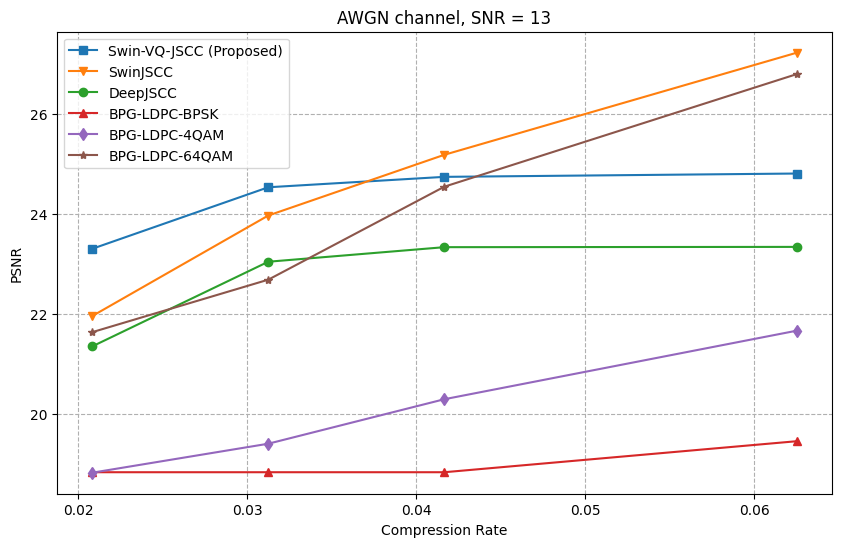

In [46]:
# SNR = 13
CBR = [1/48, 1/32, 1/24, 1/16]

swin_vq_psnr = [23.30705428123474, 24.538039684295654, 24.746255655288696, 24.81272029876709]
swinjscc_psnr = [21.961781978607178, 23.973016262054443, 25.18788766860962, 27.228396892547607]
deepjscc_psnr = [21.355137825012207, 23.048906087875366, 23.340161085128784, 23.34569478034973]
bpg_ldpc_bpsk = [18.84, 18.84, 18.84, 19.46]
bpg_ldpc_4qam = [18.83, 19.41, 20.3, 21.67]
bpg_ldpc_64qam = [21.64, 22.69, 24.55, 26.8]

# plot
plt.figure(figsize=(10, 6))
plt.plot(CBR, swin_vq_psnr, marker='s', linestyle='-', label='Swin-VQ-JSCC (Proposed)')
plt.plot(CBR, swinjscc_psnr, marker='v', linestyle='-', label='SwinJSCC')
plt.plot(CBR, deepjscc_psnr, marker='o', linestyle='-', label='DeepJSCC')
plt.plot(CBR, bpg_ldpc_bpsk, marker='^', linestyle='-', label='BPG-LDPC-BPSK')
plt.plot(CBR, bpg_ldpc_4qam, marker='d', linestyle='-', label='BPG-LDPC-4QAM')
plt.plot(CBR, bpg_ldpc_64qam, marker='*', linestyle='-', label='BPG-LDPC-64QAM')
plt.xlabel('Compression Rate')
plt.ylabel('PSNR')

plt.title('AWGN channel, SNR = 13')

plt.legend()
plt.grid(True, which='both', linestyle='--')